# 🛒 Ecommerce Sales Classification using KNN and SVM

## Project Overview

This project predicts customer purchasing behavior using machine learning classification algorithms.

The project compares the performance of two classification models:

- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

## 📚 Import Libraries

## 📂 Load the Dataset

The e-commerce sales dataset is loaded into a Pandas DataFrame.  
The first five rows are displayed to verify that the data has been imported correctly.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veri setini okuyoruz
df = pd.read_csv("/content/ecommerce_sales_analytics_5000.csv")

# Veri setinin ilk 5 satırına bakıyoruz
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 🔍 Exploratory Data Analysis (EDA)

Before building the machine learning models, the dataset is explored to understand its structure, identify missing values, and summarize the numerical features.

In [15]:
# Veri setinin satır ve sütun sayısını gösterir
print("Veri Seti Boyutu:", df.shape)

# Eksik değerleri kontrol eder
print("\nEksik Değerler:")
print(df.isnull().sum())

# Sütunların veri tiplerini gösterir
print("\nVeri Tipleri:")
print(df.dtypes)

# Sayısal sütunların istatistiksel özetini gösterir
print("\nİstatistiksel Özet:")
display(df.describe())

Veri Seti Boyutu: (5000, 13)

Eksik Değerler:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
yuksek_gelir        0
dtype: int64

Veri Tipleri:
order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
yuksek_gelir          int64
dtype: object

İstatistiksel Özet:


,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,yuksek_gelir
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,0.50000
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,0.50005
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,0.00000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,0.00000
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,0.50000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,1.00000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,1.00000


## 🧹 Data Preprocessing

A binary target variable is created based on the median revenue.

- Revenue above the median → **1**
- Revenue below the median → **0**

In [ ]:
# Gelirlerin medyan değeri buluyoruz
medyan_gelir = df['revenue'].median()

# Medyan değerin üstündekilere 1, altındakilere 0 vererek yeni bir hedef sütun yaratıyoruz
df['yuksek_gelir'] = (df['revenue'] > medyan_gelir).astype(int)

# Yeni oluşturduğumuz sütunun dağılımına bakıyoruz
print("Sınıf Dağılımı (0: Düşük Gelir, 1: Yüksek Gelir):")
print(df['yuksek_gelir'].value_counts())

Sınıf Dağılımı (0: Düşük Gelir, 1: Yüksek Gelir):
yuksek_gelir
1    2500
0    2500
Name: count, dtype: int64


## ⚙️ Data Preparation

The dataset is prepared for machine learning.

The data is divided into training and testing sets, and numerical features are standardized using **StandardScaler**.

In [ ]:
# 1. Özellikleri (X) ve Hedef Değişkeni (y) belirliyoruz
# Tahmin yapmak için sadece sayısal ve anlamlı sütunları seçiyoruz
X = df[['quantity', 'unit_price', 'discount', 'delivery_days']]
y = df['yuksek_gelir']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. k-NN ve SVM için ölçeklendirme (Scaling) yapıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("3. Adım Başarıyla Tamamlandı!")
print(f"Eğitim kümesindeki örnek sayısı: {X_train_scaled.shape[0]}")
print(f"Test kümesindeki örnek sayısı: {X_test_scaled.shape[0]}")

3. Adım Başarıyla Tamamlandı!
Eğitim kümesindeki örnek sayısı: 4000
Test kümesindeki örnek sayısı: 1000


## 🤖 Model 1: K-Nearest Neighbors (KNN)

The KNN classifier is trained using the training dataset and evaluated on the test dataset.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. k-NN modelini tanımlıyoruz (Komşu sayısını k=5 yapıyoruz)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Modeli eğitim verilerimizle eğitiyoruz
knn_model.fit(X_train_scaled, y_train)

# 3. Modelin hiç görmediği test verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_knn = knn_model.predict(X_test_scaled)

# 4. Modelin Accuracy skorunu hesaplıyoruz
dogruluk_knn = accuracy_score(y_test, y_pred_knn)

print("4. Adım: k-NN Modeli Başarıyla Eğitildi ve Test Edildi!\n")
print(f"k-NN Modelinin Doğruluk Oranı (Accuracy): %{dogruluk_knn * 100:.2f}")

4. Adım: k-NN Modeli Başarıyla Eğitildi ve Test Edildi!

k-NN Modelinin Doğruluk Oranı (Accuracy): %97.70


## 📊 KNN Confusion Matrix

The confusion matrix illustrates the classification performance of the K-Nearest Neighbors (KNN) model by comparing predicted labels with actual labels.

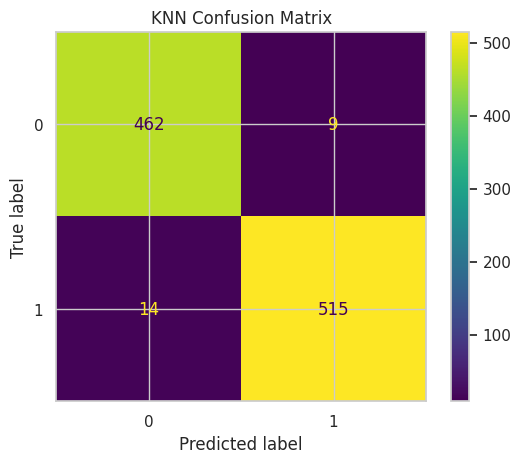

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# KNN modeli için Confusion Matrix'i görselleştir
ConfusionMatrixDisplay.from_estimator(knn_model, X_test_scaled, y_test)

plt.title("KNN Confusion Matrix")
plt.show()

## 🤖 Model 2: Support Vector Machine (SVM)

The SVM classifier is trained and evaluated using the same training and testing datasets for comparison.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. SVM modelini tanımlıyoruz (Sınıflandırma için SVC kullanıyoruz)
svm_model = SVC(kernel='linear', random_state=42)

# 2. Modeli ölçeklenmiş eğitim verilerimizle eğitiyoruz
svm_model.fit(X_train_scaled, y_train)

# 3. Modelin test verileri üzerinde tahmin yapmasını sağlıyoruz
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. SVM modelinin doğruluk (Accuracy) skorunu hesaplıyoruz
dogruluk_svm = accuracy_score(y_test, y_pred_svm)

print("5. Adım: SVM Modeli Başarıyla Eğitildi ve Test Edildi!\n")
print(f"SVM Modelinin Doğruluk Oranı (Accuracy): %{dogruluk_svm * 100:.2f}")

5. Adım: SVM Modeli Başarıyla Eğitildi ve Test Edildi!

SVM Modelinin Doğruluk Oranı (Accuracy): %91.00


## 📊 SVM Confusion Matrix

The confusion matrix illustrates the classification performance of the Support Vector Machine (SVM) model by comparing predicted labels with actual labels.

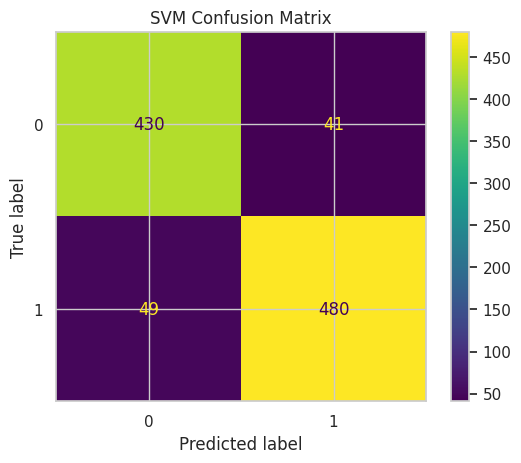

In [19]:
# SVM modeli için Confusion Matrix'i görselleştir
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_scaled, y_test)

plt.title("SVM Confusion Matrix")
plt.show()

## 📊 Model Evaluation

The performance of both models is evaluated using accuracy score, confusion matrix, and classification report.

/tmp/ipykernel_479/2970046972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=modeller, y=dogruluk_oranlari, palette="Set2")


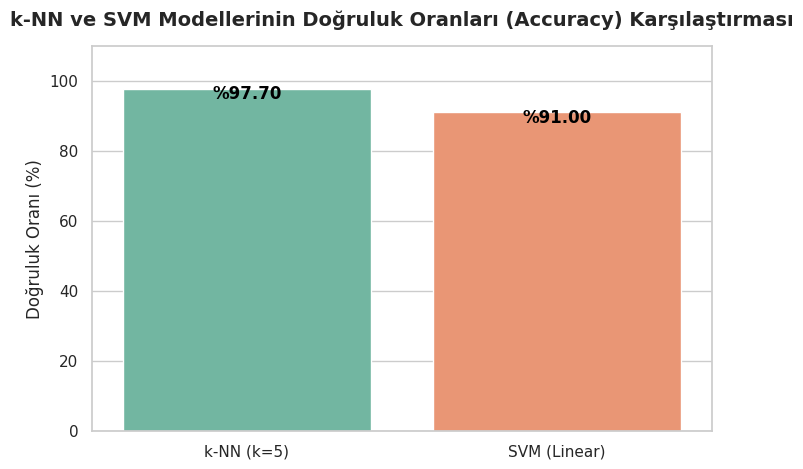

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modellerin doğruluk oranlarını bir sözlükte topluyoruz
modeller = ['k-NN (k=5)', 'SVM (Linear)']
dogruluk_oranlari = [dogruluk_knn * 100, dogruluk_svm * 100]

# 2. Grafik çizimi için arka plan stilini ayarlıyoruz
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Barplot oluşturuyoruz
ax = sns.barplot(x=modeller, y=dogruluk_oranlari, palette="Set2")

# 4. Grafiğin üzerine yüzde değerlerini yazdırıyoruz
for p in ax.patches:
    ax.annotate(f"%{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='black')

# 5. Grafik başlıkları ve sınırları
plt.title("k-NN ve SVM Modellerinin Doğruluk Oranları (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Doğruluk Oranı (%)", fontsize=12)
plt.ylim(0, 110)

# Grafiği ekranda gösteriyoruz
plt.show()

## 📊 Model Comparison

The chart below compares the accuracy scores of the K-Nearest Neighbors (KNN) and Support Vector Machine (SVM) models.

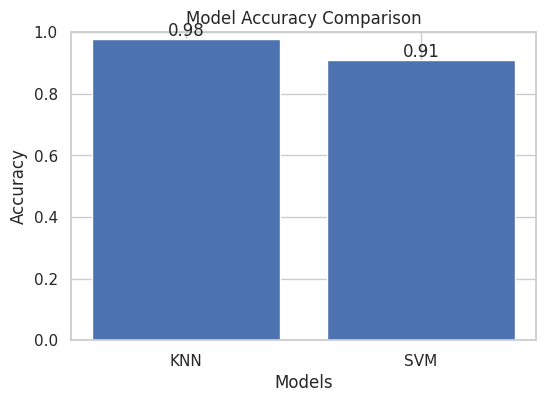

In [21]:
# Modellerin doğruluk oranlarını karşılaştırma grafiği

models = ["KNN", "SVM"]
accuracies = [dogruluk_knn, dogruluk_svm]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

plt.show()

# ✅ Conclusion

In this project, two machine learning classification algorithms were implemented to predict customer purchasing behavior.

Both models produced successful classification results, and their performances were compared using standard evaluation metrics.

Future improvements may include:

- Hyperparameter tuning
- Cross-validation
- Random Forest
- XGBoost
- More feature engineering